<a href="https://colab.research.google.com/github/kalalasrinika-star/-student-profile/blob/main/Car_Price_Prediction_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving car data.csv to car data.csv


In [2]:
import pandas as pd
# Load the dataset
df = pd.read_csv('/content/car data.csv')
# Display the first 5 rows
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
print("Dataset Information:")
df.info()
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB

Missing Values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [ ]:
# Remove Car_Name
df = df.drop('Car_Name', axis=1)
# Convert categorical columns into numerical columns
df = pd.get_dummies(df, columns=['Fuel_Type', 'Selling_type', 'Transmission'], drop_first=True)
# Display the updated dataset
df.head()

,Year,Selling_Price,Present_Price,Driven_kms,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,2014,3.35,5.59,27000,0,False,True,False,True
1,2013,4.75,9.54,43000,0,True,False,False,True
2,2017,7.25,9.85,6900,0,False,True,False,True
3,2011,2.85,4.15,5200,0,False,True,False,True
4,2014,4.60,6.87,42450,0,True,False,False,True


In [ ]:
# Separate features and target
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']
# Display the shapes
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (301, 8)
Target shape: (301,)


In [ ]:
from sklearn.model_selection import train_test_split
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (240, 8)
Testing data: (61, 8)


In [ ]:
from sklearn.linear_model import LinearRegression
# Create the model
model = LinearRegression()
# Train the model
model.fit(X_train, y_train)
print("Model training completed successfully!")

Model training completed successfully!


In [ ]:
# Predict car prices
y_pred = model.predict(X_test)
# Display the first 10 predictions
print("Predicted prices:")
print(y_pred[:10])

Predicted prices:
[ 2.95433731  8.17716341  6.45612271 -1.42337164  9.08864657  7.41793553
  1.33513921  0.84032259  1.36320242  7.49067757]


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("Model Evaluation:")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

Model Evaluation:
MAE : 1.2163740193336217
MSE : 3.4813498305146187
RMSE: 1.865837568094988
R2 Score: 0.8488707839191938


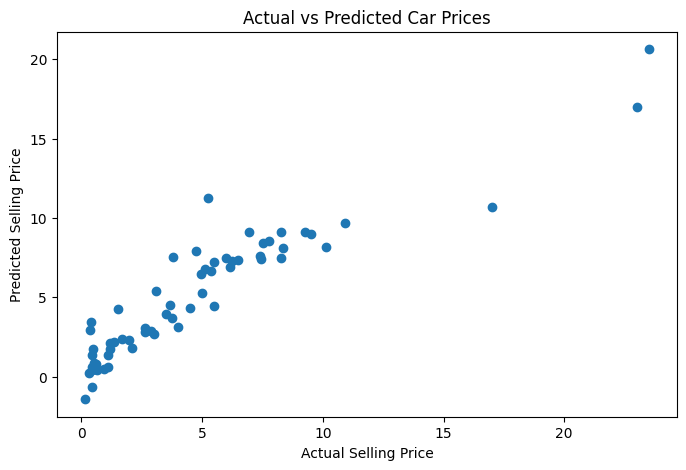

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()

In [ ]:
results = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})
print(results.head(10))

   Actual Price  Predicted Price
0          0.35         2.954337
1         10.11         8.177163
2          4.95         6.456123
3          0.15        -1.423372
4          6.95         9.088647
5          7.45         7.417936
6          1.10         1.335139
7          0.50         0.840323
8          0.45         1.363202
9          6.00         7.490678


Conclusion:
A Linear Regression model was developed to predict used car selling prices based on features such as year, present price, driven kilometers, fuel type, selling type, transmission, and owner. The data was preprocessed and categorical features were converted into numerical values. The model achieved an R² score of approximately 0.85, showing good predictive performance on the test data. This project demonstrates a real-world application of machine learning for car price prediction.